# MT-Bench EDA

Exploratory data analysis of the MT-Bench dataset.

**Dataset:** lmsys/mt_bench_human_judgments (HuggingFace)  
**Key filter:** Most analysis uses `turn == 1` only (1,689 rows out of 3,355 total)

In [2]:
import ast
import warnings

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110

DATA_PATH = "../data/mt_bench.csv"

## 1. Load & Inspect

In [3]:
df = pd.read_csv("data/mt_bench.csv")

print(f"Shape: {df.shape}")
print(f"\nColumn dtypes:")
print(df.dtypes)
print(f"\nNull counts:")
print(df.isnull().sum())

Shape: (3355, 8)

Column dtypes:
question_id        int64
model_a           object
model_b           object
winner            object
judge             object
conversation_a    object
conversation_b    object
turn               int64
dtype: object

Null counts:
question_id       0
model_a           0
model_b           0
winner            0
judge             0
conversation_a    0
conversation_b    0
turn              0
dtype: int64


In [4]:
df.head(3)

,question_id,model_a,model_b,winner,judge,conversation_a,conversation_b,turn
0,81,alpaca-13b,gpt-3.5-turbo,model_b,author_2,[{'content': 'Compose an engaging travel blog ...,[{'content': 'Compose an engaging travel blog ...,1
1,81,alpaca-13b,gpt-3.5-turbo,model_b,author_2,[{'content': 'Compose an engaging travel blog ...,[{'content': 'Compose an engaging travel blog ...,2
2,81,alpaca-13b,gpt-3.5-turbo,model_b,expert_17,[{'content': 'Compose an engaging travel blog ...,[{'content': 'Compose an engaging travel blog ...,1


## 2. Dataset Overview

In [5]:
print("Rows by turn:")
print(df["turn"].value_counts().sort_index())

t1 = df[df["turn"] == 1]
print(f"\nTurn=1 rows : {len(t1):,}  (used for all bias analysis)")
print(f"Unique questions : {t1['question_id'].nunique()}")
print(f"Unique models    : {sorted(set(t1['model_a'].unique()) | set(t1['model_b'].unique()))}")
print(f"Unique judges    : {t1['judge'].nunique()}")

Rows by turn:
1    1689
2    1666
Name: turn, dtype: int64

Turn=1 rows : 1,689  (used for all bias analysis)
Unique questions : 80
Unique models    : ['alpaca-13b', 'claude-v1', 'gpt-3.5-turbo', 'gpt-4', 'llama-13b', 'vicuna-13b-v1.2']
Unique judges    : 65


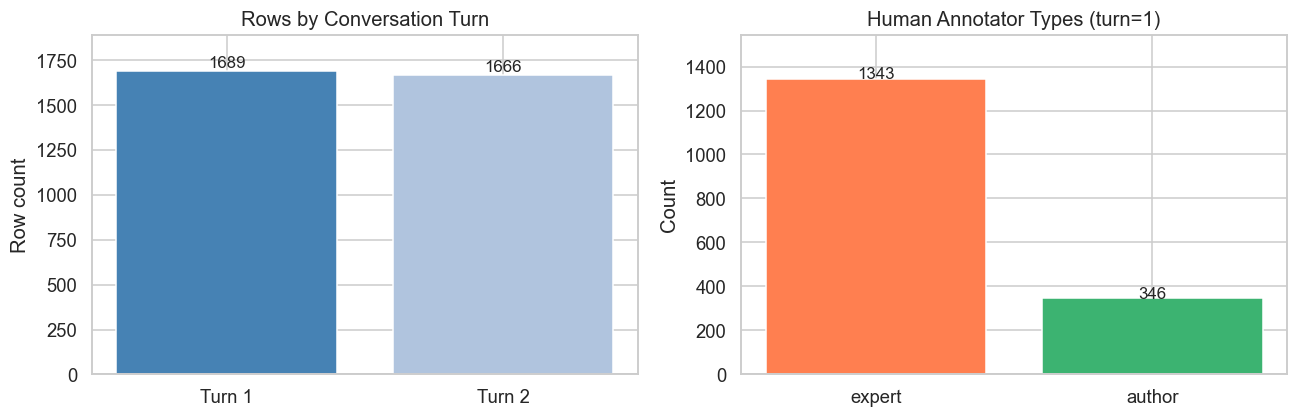

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Turn distribution
turn_counts = df["turn"].value_counts().sort_index()
axes[0].bar(["Turn 1", "Turn 2"], turn_counts.values, color=["steelblue", "lightsteelblue"])
for i, v in enumerate(turn_counts.values):
    axes[0].text(i, v + 20, str(v), ha="center", fontsize=11)
axes[0].set_title("Rows by Conversation Turn")
axes[0].set_ylabel("Row count")
axes[0].set_ylim(0, turn_counts.max() * 1.12)

# Judge type breakdown
judge_types = t1["judge"].str.extract(r'^(author|expert)')[0].value_counts()
axes[1].bar(judge_types.index, judge_types.values, color=["coral", "mediumseagreen"])
for i, v in enumerate(judge_types.values):
    axes[1].text(i, v + 0.5, str(v), ha="center", fontsize=11)
axes[1].set_title("Human Annotator Types (turn=1)")
axes[1].set_ylabel("Count")
axes[1].set_ylim(0, judge_types.max() * 1.15)

plt.tight_layout()
plt.show()

## 3. Human Verdict Distribution

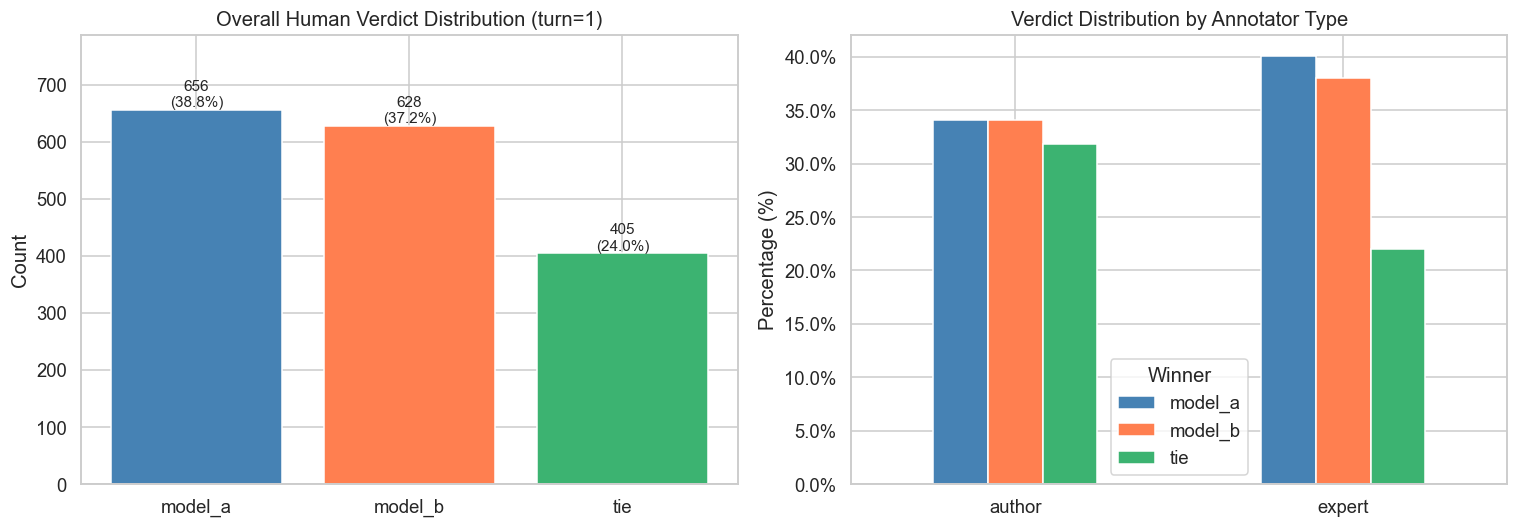

Overall human tie rate: 24.0%
(LLM judges call ties ~3% for Claude Haiku, ~0.2% for Llama — see calibration results)


In [7]:
winner_order = ["model_a", "model_b", "tie"]
palette = {"model_a": "steelblue", "model_b": "coral", "tie": "mediumseagreen"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall
overall = t1["winner"].value_counts().reindex(winner_order)
bars = axes[0].bar(overall.index, overall.values,
                   color=[palette[w] for w in overall.index])
for bar, v in zip(bars, overall.values):
    pct = 100 * v / overall.sum()
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + 5,
                 f"{v}\n({pct:.1f}%)", ha="center", fontsize=10)
axes[0].set_title("Overall Human Verdict Distribution (turn=1)")
axes[0].set_ylabel("Count")
axes[0].set_ylim(0, overall.max() * 1.2)

# By judge type
t1_typed = t1.copy()
t1_typed["judge_type"] = t1["judge"].str.extract(r'^(author|expert)')[0]
judge_winner = (t1_typed.groupby(["judge_type", "winner"])
                .size().reset_index(name="count"))
judge_pivot = judge_winner.pivot(index="judge_type", columns="winner", values="count").fillna(0)
judge_pct = judge_pivot.div(judge_pivot.sum(axis=1), axis=0) * 100
judge_pct[winner_order].plot(kind="bar", ax=axes[1],
                              color=[palette[w] for w in winner_order],
                              rot=0, legend=True)
axes[1].set_title("Verdict Distribution by Annotator Type")
axes[1].set_ylabel("Percentage (%)")
axes[1].set_xlabel("")
axes[1].legend(title="Winner")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.show()

tie_rate = 100 * (t1["winner"] == "tie").mean()
print(f"Overall human tie rate: {tie_rate:.1f}%")
print("(LLM judges call ties ~3% for Claude Haiku, ~0.2% for Llama — see calibration results)")

## 4. Model Pair Analysis

In [8]:
# Order-invariant pair_id (matches project convention)
t1 = t1.copy()
t1["pair_id"] = t1.apply(
    lambda r: str(r["question_id"]) + "_" + "_".join(sorted([r["model_a"], r["model_b"]])),
    axis=1,
)

models = sorted(set(t1["model_a"].unique()) | set(t1["model_b"].unique()))
print(f"Models ({len(models)}): {models}")
print(f"\nUnique pairs: {t1['pair_id'].nunique()}")

Models (6): ['alpaca-13b', 'claude-v1', 'gpt-3.5-turbo', 'gpt-4', 'llama-13b', 'vicuna-13b-v1.2']

Unique pairs: 910


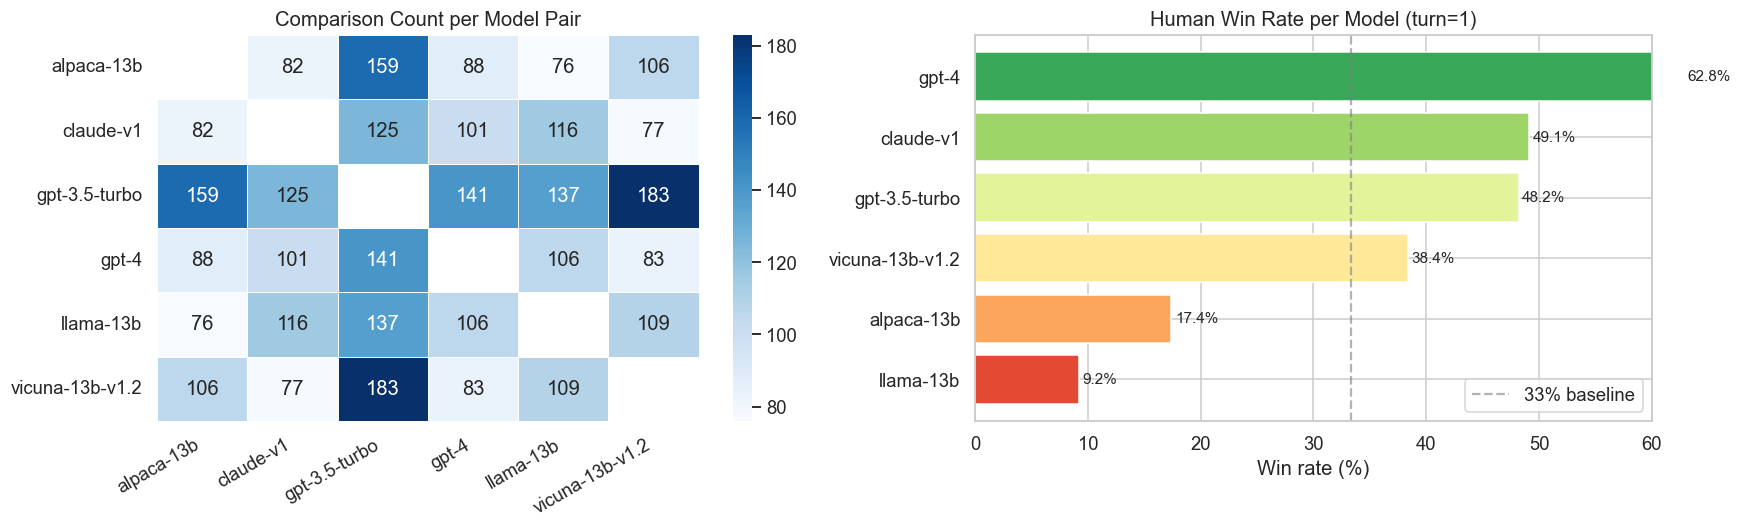

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Comparison count heatmap (order-invariant)
pair_counts = pd.DataFrame(0, index=models, columns=models)
for _, row in t1.iterrows():
    pair_counts.loc[row["model_a"], row["model_b"]] += 1
    pair_counts.loc[row["model_b"], row["model_a"]] += 1

mask = np.eye(len(models), dtype=bool)
sns.heatmap(pair_counts, annot=True, fmt="d", cmap="Blues",
            mask=mask, ax=axes[0], linewidths=0.5)
axes[0].set_title("Comparison Count per Model Pair")
axes[0].set_xlabel("")
axes[0].set_ylabel("")
plt.setp(axes[0].get_xticklabels(), rotation=30, ha="right")

# Win rate per model
wins = {}
for m in models:
    rows_a = t1[t1["model_a"] == m]
    rows_b = t1[t1["model_b"] == m]
    total = len(rows_a) + len(rows_b)
    win_count = ((rows_a["winner"] == "model_a").sum() +
                 (rows_b["winner"] == "model_b").sum())
    wins[m] = 100 * win_count / total if total > 0 else 0

win_series = pd.Series(wins).sort_values(ascending=True)
colors = sns.color_palette("RdYlGn", len(models))
axes[1].barh(win_series.index, win_series.values, color=colors)
axes[1].axvline(33.3, ls="--", color="gray", alpha=0.6, label="33% baseline")
for i, v in enumerate(win_series.values):
    axes[1].text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=10)
axes[1].set_title("Human Win Rate per Model (turn=1)")
axes[1].set_xlabel("Win rate (%)")
axes[1].set_xlim(0, 60)
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Answer Length Analysis

Motivates the verbosity bias test: do LLM judges prefer longer answers independent of quality?

In [10]:
def extract_answer(conv_raw: str) -> str:
    """Extract first assistant response from a stringified conversation list."""
    conv = ast.literal_eval(conv_raw) if isinstance(conv_raw, str) else conv_raw
    for turn in conv:
        if turn.get("role") == "assistant":
            return turn.get("content", "")
    return ""

print("Parsing conversations...")
t1["answer_a"] = t1["conversation_a"].apply(extract_answer)
t1["answer_b"] = t1["conversation_b"].apply(extract_answer)
t1["len_a"] = t1["answer_a"].str.split().str.len()
t1["len_b"] = t1["answer_b"].str.split().str.len()
t1["longer"] = t1.apply(
    lambda r: "A" if r["len_a"] > r["len_b"] else ("B" if r["len_b"] > r["len_a"] else "equal"),
    axis=1,
)
print(f"Median len_a: {t1['len_a'].median():.0f} words")
print(f"Median len_b: {t1['len_b'].median():.0f} words")

Parsing conversations...
Median len_a: 111 words
Median len_b: 111 words


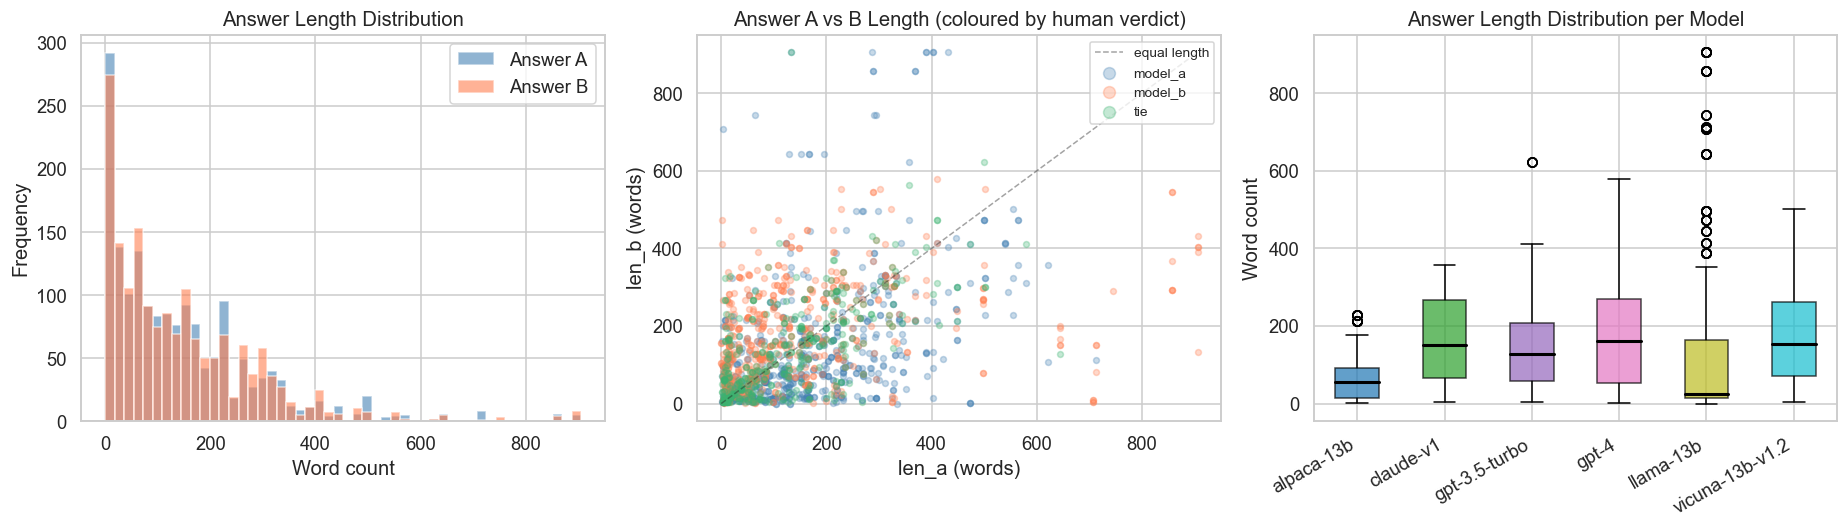

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Answer length histograms
axes[0].hist(t1["len_a"], bins=50, alpha=0.6, label="Answer A", color="steelblue")
axes[0].hist(t1["len_b"], bins=50, alpha=0.6, label="Answer B", color="coral")
axes[0].set_title("Answer Length Distribution")
axes[0].set_xlabel("Word count")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# Scatter: len_a vs len_b colored by winner
scatter_colors = {"model_a": "steelblue", "model_b": "coral", "tie": "mediumseagreen"}
for w, grp in t1.groupby("winner"):
    axes[1].scatter(grp["len_a"], grp["len_b"], alpha=0.3, s=15,
                    color=scatter_colors[w], label=w, rasterized=True)
max_len = max(t1["len_a"].max(), t1["len_b"].max())
axes[1].plot([0, max_len], [0, max_len], "k--", alpha=0.4, lw=1, label="equal length")
axes[1].set_title("Answer A vs B Length (colored by human verdict)")
axes[1].set_xlabel("len_a (words)")
axes[1].set_ylabel("len_b (words)")
axes[1].legend(markerscale=2, fontsize=9)

# Box plot: answer length per model
model_lengths = []
for m in models:
    lens_a = t1.loc[t1["model_a"] == m, "len_a"]
    lens_b = t1.loc[t1["model_b"] == m, "len_b"]
    combined = pd.concat([lens_a, lens_b])
    model_lengths.append(combined.values)

bp = axes[2].boxplot(model_lengths, tick_labels=models, patch_artist=True,
                     medianprops=dict(color="black", linewidth=2))
cmap = plt.get_cmap("tab10", len(models))
for patch, color in zip(bp["boxes"], [cmap(i) for i in range(len(models))]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[2].set_title("Answer Length Distribution per Model")
axes[2].set_ylabel("Word count")
axes[2].set_xlabel("")
plt.setp(axes[2].get_xticklabels(), rotation=30, ha="right")

plt.tight_layout()
plt.show()

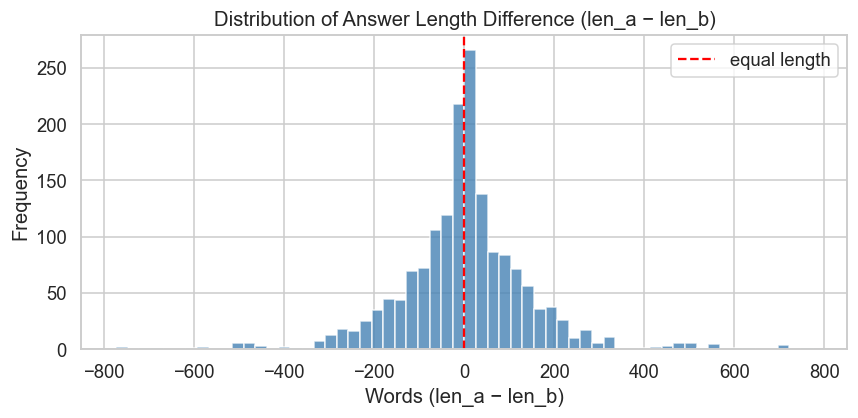

A longer than B: 48.7%
Roughly symmetric — no systematic positional length bias in the dataset


In [12]:
# Length difference distribution — what the verbosity model uses
t1["length_diff"] = t1["len_a"] - t1["len_b"]
t1["length_diff_100"] = t1["length_diff"] / 100  # 100-word units (matches mixed_effects.py)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(t1["length_diff"], bins=60, color="steelblue", alpha=0.8, edgecolor="white")
ax.axvline(0, color="red", ls="--", lw=1.5, label="equal length")
ax.set_title("Distribution of Answer Length Difference (len_a − len_b)")
ax.set_xlabel("Words (len_a − len_b)")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.show()

pct_a_longer = 100 * (t1["length_diff"] > 0).mean()
print(f"A longer than B: {pct_a_longer:.1f}%")
print(f"Roughly symmetric — no systematic positional length bias in the dataset")

## 6. Human Agreement Baseline

For each question, how often do annotators agree with each other? Measures question difficulty/subjectivity.

In [13]:
def majority_verdict(verdicts):
    counts = verdicts.value_counts()
    return counts.idxmax()

# Per-question majority verdict
majority = t1.groupby("question_id")["winner"].agg(majority_verdict).rename("majority")
t1_agree = t1.join(majority, on="question_id")
t1_agree["agrees_with_majority"] = t1_agree["winner"] == t1_agree["majority"]

# Per-question agreement rate
q_agreement = t1_agree.groupby("question_id")["agrees_with_majority"].mean()

print(f"Mean per-question agreement rate: {q_agreement.mean():.2%}")
print(f"Min: {q_agreement.min():.2%}   Max: {q_agreement.max():.2%}")

Mean per-question agreement rate: 49.05%
Min: 35.29%   Max: 95.24%


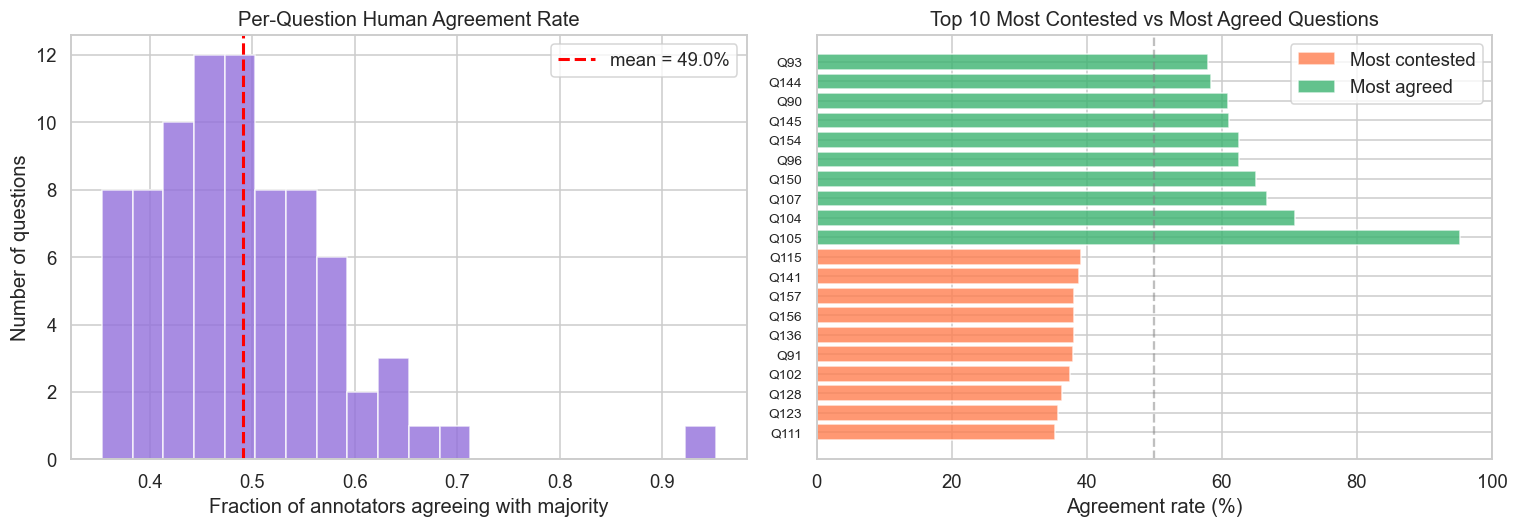

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of per-question agreement rates
axes[0].hist(q_agreement.values, bins=20, color="mediumpurple", alpha=0.8, edgecolor="white")
axes[0].axvline(q_agreement.mean(), color="red", ls="--", lw=2,
                label=f"mean = {q_agreement.mean():.1%}")
axes[0].set_title("Per-Question Human Agreement Rate")
axes[0].set_xlabel("Fraction of annotators agreeing with majority")
axes[0].set_ylabel("Number of questions")
axes[0].legend()

# Most contested vs most agreed-upon
top10_contested = q_agreement.nsmallest(10)
top10_agreed = q_agreement.nlargest(10)

axes[1].barh(range(10), top10_contested.values * 100, color="coral", alpha=0.8,
             label="Most contested")
axes[1].barh(range(10, 20), top10_agreed.values * 100, color="mediumseagreen", alpha=0.8,
             label="Most agreed")
axes[1].set_yticks(range(20))
axes[1].set_yticklabels(
    [f"Q{qid}" for qid in top10_contested.index] +
    [f"Q{qid}" for qid in top10_agreed.index],
    fontsize=9
)
axes[1].axvline(50, color="gray", ls="--", alpha=0.5)
axes[1].set_title("Top 10 Most Contested vs Most Agreed Questions")
axes[1].set_xlabel("Agreement rate (%)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Questions by Category

MT-Bench covers 8 categories across 80 questions (question_ids 81–160, 10 per category).

In [15]:
CATEGORY_MAP = {
    range(81, 91):  "writing",
    range(91, 101): "roleplay",
    range(101, 111): "reasoning",
    range(111, 121): "math",
    range(121, 131): "coding",
    range(131, 141): "extraction",
    range(141, 151): "stem",
    range(151, 161): "humanities",
}

def get_category(qid):
    for r, cat in CATEGORY_MAP.items():
        if qid in r:
            return cat
    return "unknown"

t1["category"] = t1["question_id"].apply(get_category)

print("Rows per category:")
print(t1.groupby("category").size().sort_values(ascending=False))

Rows per category:
category
roleplay      234
humanities    227
reasoning     218
stem          210
math          207
extraction    203
coding        200
writing       190
dtype: int64


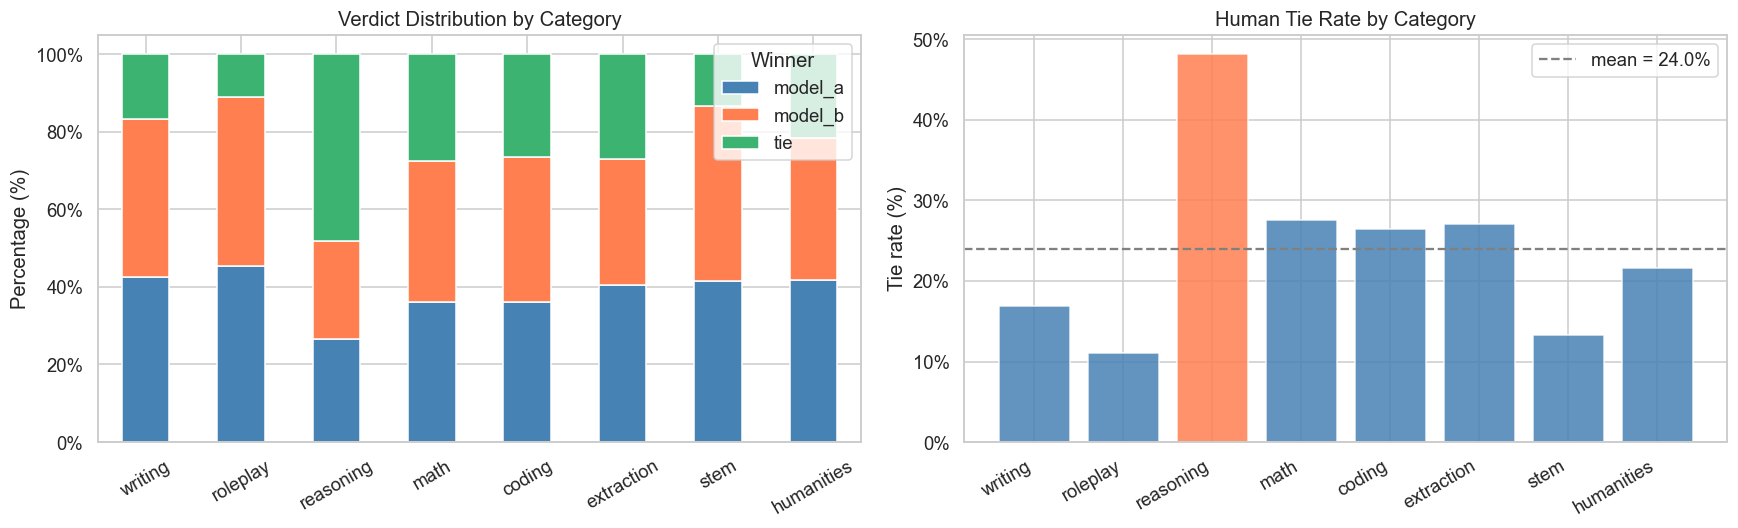

In [16]:
cat_order = ["writing", "roleplay", "reasoning", "math", "coding",
             "extraction", "stem", "humanities"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Winner distribution per category (stacked %)
cat_winner = (t1.groupby(["category", "winner"]).size()
              .unstack(fill_value=0)
              .reindex(cat_order))
cat_winner_pct = cat_winner.div(cat_winner.sum(axis=1), axis=0) * 100
cat_winner_pct[["model_a", "model_b", "tie"]].plot(
    kind="bar", stacked=True, ax=axes[0],
    color=["steelblue", "coral", "mediumseagreen"],
    rot=30
)
axes[0].set_title("Verdict Distribution by Category")
axes[0].set_ylabel("Percentage (%)")
axes[0].set_xlabel("")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[0].legend(title="Winner", loc="upper right")

# Tie rate per category
tie_rate_cat = (cat_winner_pct["tie"] if "tie" in cat_winner_pct.columns
                else pd.Series(0, index=cat_order))
colors_cat = ["coral" if v == tie_rate_cat.max() else "steelblue"
              for v in tie_rate_cat.values]
axes[1].bar(tie_rate_cat.index, tie_rate_cat.values, color=colors_cat, alpha=0.85)
axes[1].axhline(tie_rate_cat.mean(), color="gray", ls="--",
                label=f"mean = {tie_rate_cat.mean():.1f}%")
axes[1].set_title("Human Tie Rate by Category")
axes[1].set_ylabel("Tie rate (%)")
axes[1].set_xlabel("")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
plt.setp(axes[1].get_xticklabels(), rotation=30, ha="right")
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Human Verbosity Preference

Do humans also favor longer answers? If yes, the judge is mirroring human behavior. If not, verbosity bias is a judge-specific artifact.

Human picks longer answer : 53.2%
Human picks shorter answer: 24.0%
Human calls tie           : 22.8%



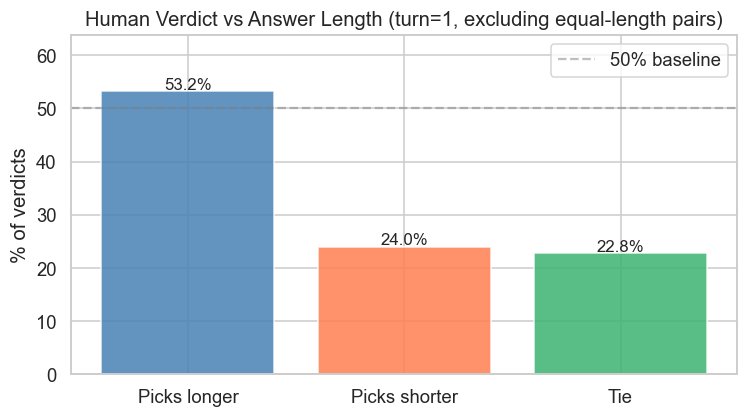

In [17]:
# Requires answer lengths from section 5 — run that section first
t1_vb = t1[t1["longer"] != "equal"].copy()
t1_vb["human_picked_longer"] = (
    ((t1_vb["longer"] == "A") & (t1_vb["winner"] == "model_a")) |
    ((t1_vb["longer"] == "B") & (t1_vb["winner"] == "model_b"))
)
t1_vb["human_picked_shorter"] = (
    ((t1_vb["longer"] == "A") & (t1_vb["winner"] == "model_b")) |
    ((t1_vb["longer"] == "B") & (t1_vb["winner"] == "model_a"))
)

pct_longer = 100 * t1_vb["human_picked_longer"].mean()
pct_shorter = 100 * t1_vb["human_picked_shorter"].mean()
pct_tie = 100 * (1 - t1_vb["human_picked_longer"].mean() - t1_vb["human_picked_shorter"].mean())

print(f"Human picks longer answer : {pct_longer:.1f}%")
print(f"Human picks shorter answer: {pct_shorter:.1f}%")
print(f"Human calls tie           : {pct_tie:.1f}%")
print()


fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(["Picks longer", "Picks shorter", "Tie"],
              [pct_longer, pct_shorter, pct_tie],
              color=["steelblue", "coral", "mediumseagreen"], alpha=0.85)
for bar, v in zip(bars, [pct_longer, pct_shorter, pct_tie]):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.3, f"{v:.1f}%", ha="center", fontsize=11)
ax.axhline(50, color="gray", ls="--", alpha=0.5, label="50% baseline")
ax.set_title("Human Verdict vs Answer Length (turn=1, excluding equal-length pairs)")
ax.set_ylabel("% of verdicts")
ax.set_ylim(0, max(pct_longer, pct_shorter, pct_tie) * 1.2)
ax.legend()
plt.tight_layout()
plt.show()

## 9. Positional Bias in Human Labels

Is `model_a` already winning more often than `model_b` in the raw human data? A pre-existing imbalance would confound the judge positional bias measurement.

model_a wins: 38.8%
model_b wins: 37.2%
tie         : 24.0%
Difference (model_a - model_b): +1.7pp
A near-zero difference means the dataset has no inherent positional bias in human labels.


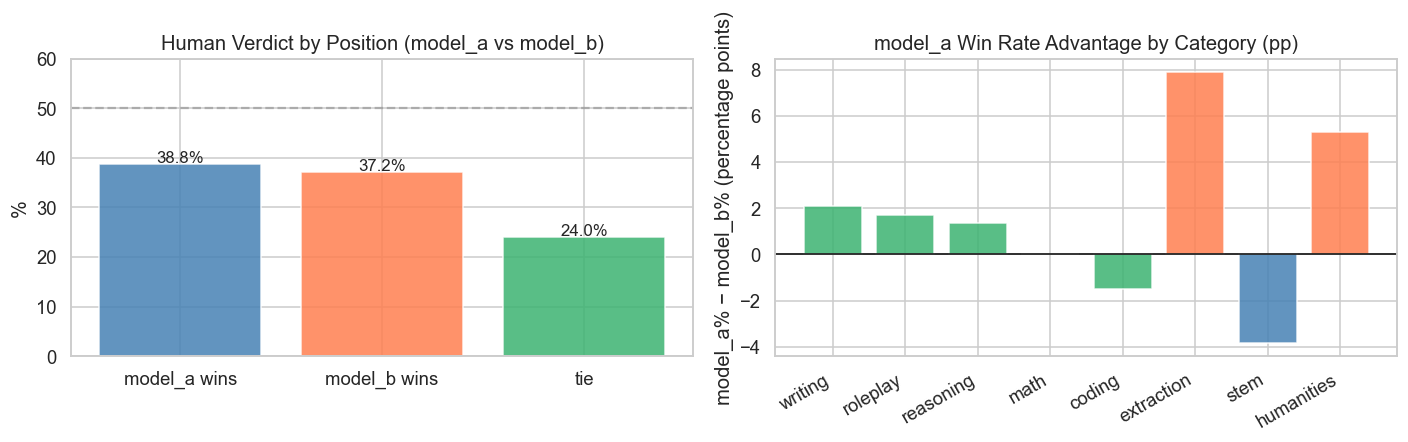

In [18]:
pos_counts = t1["winner"].value_counts()
pct_model_a = 100 * (t1["winner"] == "model_a").mean()
pct_model_b = 100 * (t1["winner"] == "model_b").mean()
pct_tie_pos = 100 * (t1["winner"] == "tie").mean()

print(f"model_a wins: {pct_model_a:.1f}%")
print(f"model_b wins: {pct_model_b:.1f}%")
print(f"tie         : {pct_tie_pos:.1f}%")
print(f"Difference (model_a - model_b): {pct_model_a - pct_model_b:+.1f}pp")
print("A near-zero difference means the dataset has no inherent positional bias in human labels.")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Overall positional balance
axes[0].bar(["model_a wins", "model_b wins", "tie"],
            [pct_model_a, pct_model_b, pct_tie_pos],
            color=["steelblue", "coral", "mediumseagreen"], alpha=0.85)
axes[0].axhline(50, color="gray", ls="--", alpha=0.5)
for i, v in enumerate([pct_model_a, pct_model_b, pct_tie_pos]):
    axes[0].text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=11)
axes[0].set_title("Human Verdict by Position (model_a vs model_b)")
axes[0].set_ylabel("%")
axes[0].set_ylim(0, 60)

# Per-category positional balance
cat_pos = t1.groupby("category").apply(
    lambda g: 100 * (g["winner"] == "model_a").mean() - 100 * (g["winner"] == "model_b").mean()
).reindex(cat_order)
colors_pos = ["coral" if v > 3 else ("steelblue" if v < -3 else "mediumseagreen") for v in cat_pos]
axes[1].bar(cat_pos.index, cat_pos.values, color=colors_pos, alpha=0.85)
axes[1].axhline(0, color="black", lw=1)
axes[1].set_title("model_a Win Rate Advantage by Category (pp)")
axes[1].set_ylabel("model_a% − model_b% (percentage points)")
plt.setp(axes[1].get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 10. Per-Annotator Model Preference

Do individual annotators systematically favor certain models? Outlier annotators inflate apparent human agreement and motivate comparing judge verdicts against individual rows (not majority vote).

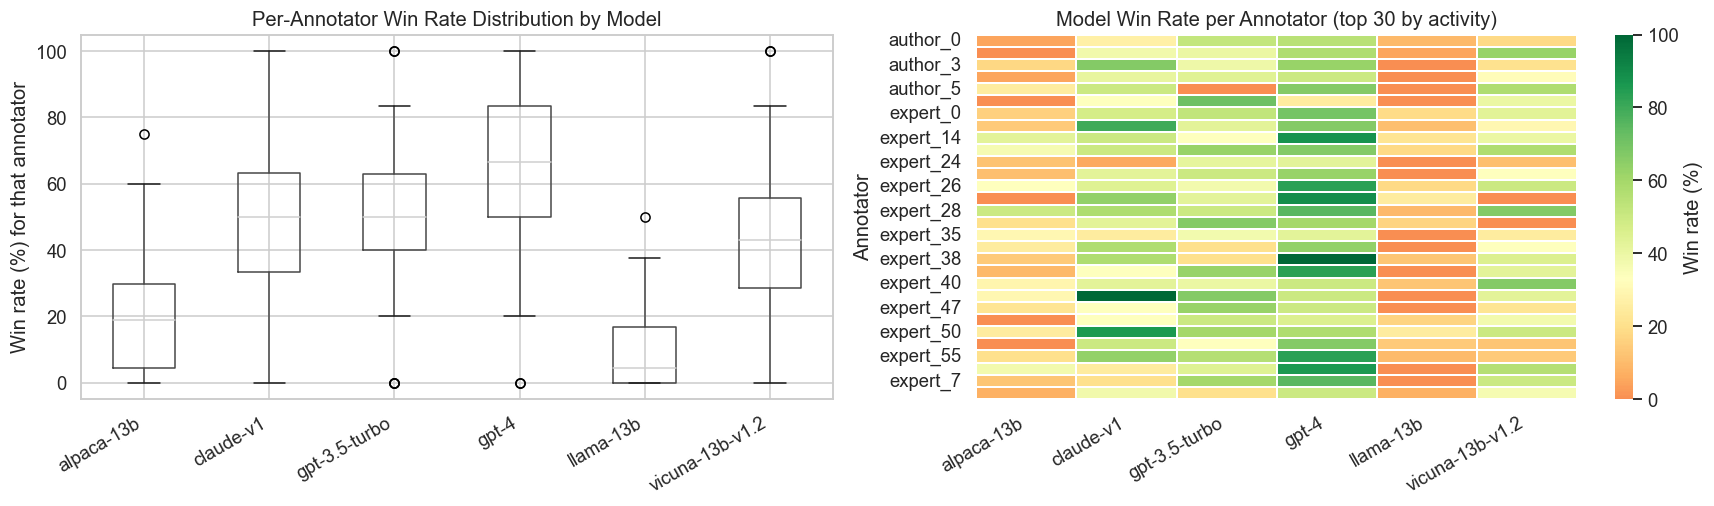

Std of per-annotator win rates across models:
model
alpaca-13b         16.4
claude-v1          24.1
gpt-3.5-turbo      20.3
gpt-4              22.9
llama-13b          11.7
vicuna-13b-v1.2    21.9


In [19]:
# Win rate for each model per annotator
annotators = t1["judge"].unique()
model_list = sorted(set(t1["model_a"].unique()) | set(t1["model_b"].unique()))

rows = []
for ann in annotators:
    sub = t1[t1["judge"] == ann]
    for m in model_list:
        rows_a = sub[sub["model_a"] == m]
        rows_b = sub[sub["model_b"] == m]
        total = len(rows_a) + len(rows_b)
        if total == 0:
            continue
        wins = (rows_a["winner"] == "model_a").sum() + (rows_b["winner"] == "model_b").sum()
        rows.append({"judge": ann, "model": m, "win_rate": 100 * wins / total, "n": total})

ann_df = pd.DataFrame(rows)
pivot = ann_df.pivot_table(index="judge", columns="model", values="win_rate")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribution of per-annotator win rates per model
ann_df.boxplot(column="win_rate", by="model", ax=axes[0], patch_artist=False)
axes[0].set_title("Per-Annotator Win Rate Distribution by Model")
axes[0].set_xlabel("")
axes[0].set_ylabel("Win rate (%) for that annotator")
plt.sca(axes[0])
plt.xticks(rotation=30, ha="right")
plt.suptitle("")

# Heatmap of annotator x model win rates (sample: top 30 annotators by row count)
top_ann = t1["judge"].value_counts().head(30).index
pivot_top = pivot.loc[pivot.index.isin(top_ann)].fillna(0)
sns.heatmap(pivot_top, annot=False, cmap="RdYlGn", center=33, ax=axes[1],
            linewidths=0.3, cbar_kws={"label": "Win rate (%)"})
axes[1].set_title("Model Win Rate per Annotator (top 30 by activity)")
axes[1].set_xlabel("")
axes[1].set_ylabel("Annotator")
plt.setp(axes[1].get_xticklabels(), rotation=30, ha="right")

plt.tight_layout()
plt.show()

print(f"Std of per-annotator win rates across models:")
print(ann_df.groupby("model")["win_rate"].std().round(1).to_string())

## 11. Inter-Annotator Agreement per Pair

For the same question + model pair, how often do annotators agree? This shows how hard the task is for humans and sets the ceiling for any automated judge.

Pairs with perfect agreement (100%): 1065 / 1204
Mean pair agreement rate: 94.64%
Pairs with agreement < 50%: 8


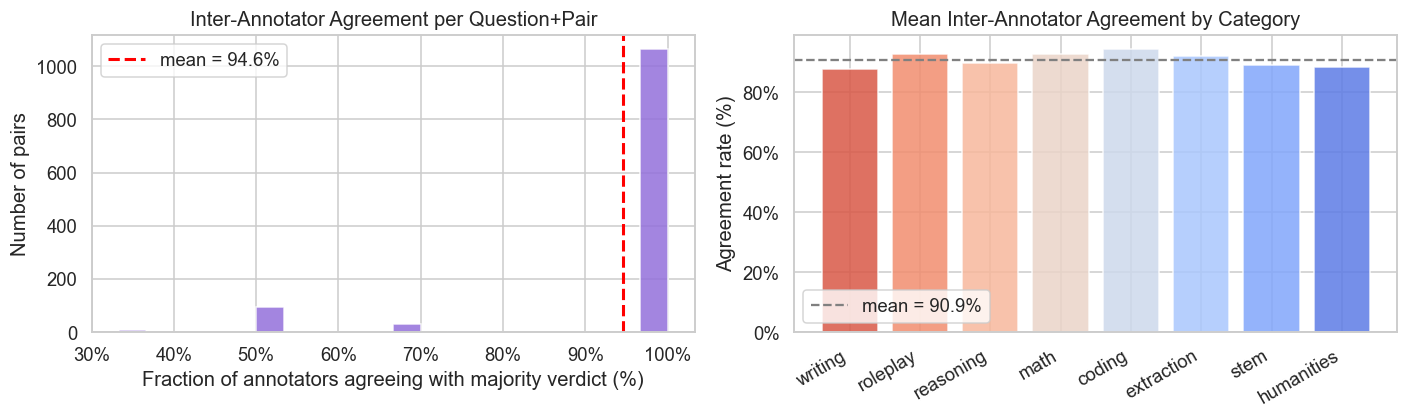

In [20]:
# For each (question_id, model_a, model_b) group, compute fraction agreeing with the majority
pair_cols = ["question_id", "model_a", "model_b"]
pair_agree = (t1.groupby(pair_cols)
              .apply(lambda g: g["winner"].value_counts().iloc[0] / len(g))
              .reset_index(name="agreement_rate"))

print(f"Pairs with perfect agreement (100%): {(pair_agree['agreement_rate'] == 1.0).sum()} / {len(pair_agree)}")
print(f"Mean pair agreement rate: {pair_agree['agreement_rate'].mean():.2%}")
print(f"Pairs with agreement < 50%: {(pair_agree['agreement_rate'] < 0.5).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(pair_agree["agreement_rate"] * 100, bins=20,
             color="mediumpurple", alpha=0.85, edgecolor="white")
axes[0].axvline(pair_agree["agreement_rate"].mean() * 100, color="red", ls="--", lw=2,
                label=f"mean = {pair_agree['agreement_rate'].mean():.1%}")
axes[0].set_title("Inter-Annotator Agreement per Question+Pair")
axes[0].set_xlabel("Fraction of annotators agreeing with majority verdict (%)")
axes[0].set_ylabel("Number of pairs")
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter())
axes[0].legend()

# Agreement rate by category
pair_agree_cat = t1.merge(pair_agree, on=pair_cols)
cat_agree = pair_agree_cat.groupby("category")["agreement_rate"].mean().reindex(cat_order) * 100
axes[1].bar(cat_agree.index, cat_agree.values,
            color=sns.color_palette("coolwarm_r", len(cat_order)), alpha=0.85)
axes[1].axhline(cat_agree.mean(), color="gray", ls="--",
                label=f"mean = {cat_agree.mean():.1f}%")
axes[1].set_title("Mean Inter-Annotator Agreement by Category")
axes[1].set_ylabel("Agreement rate (%)")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
plt.setp(axes[1].get_xticklabels(), rotation=30, ha="right")
axes[1].legend()

plt.tight_layout()
plt.show()

## 12. Head-to-Head Win Rate Matrix

Directed win rate for each model pair — reveals the quality hierarchy that confounds raw verbosity bias (better models write longer answers *and* win more).

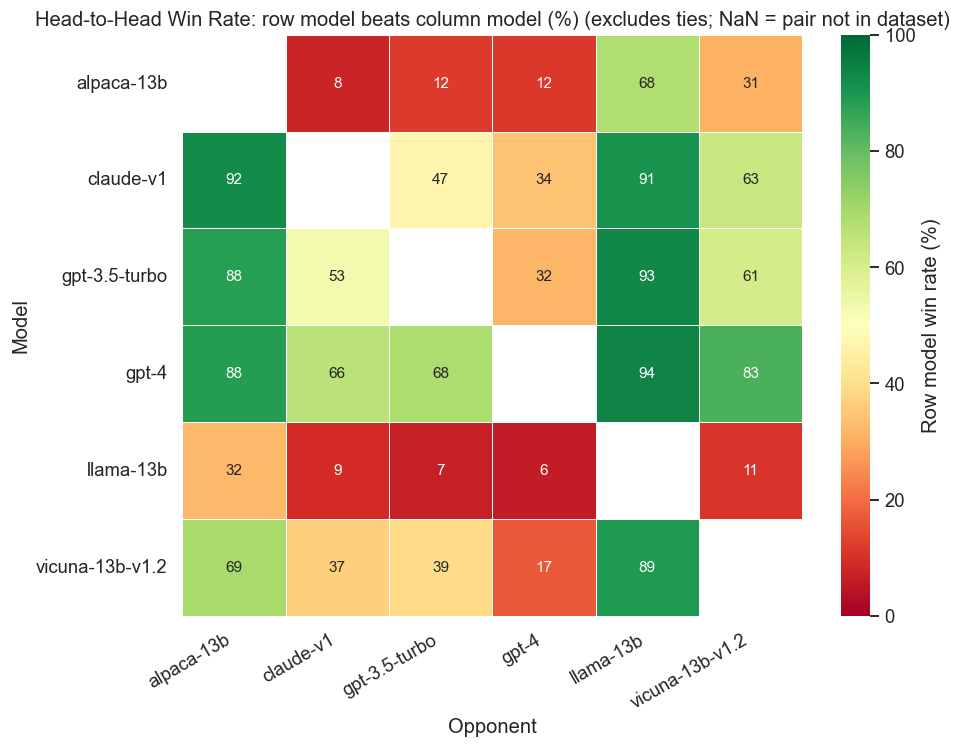

Model quality ranking by overall win rate:
gpt-4              62.813102
claude-v1          49.101796
gpt-3.5-turbo      48.187919
vicuna-13b-v1.2    38.351254
alpaca-13b         17.416830
llama-13b           9.191176


In [21]:
# Directed win rate: row model beats column model X% of the time
win_matrix = pd.DataFrame(np.nan, index=models, columns=models)
count_matrix = pd.DataFrame(0, index=models, columns=models)

for _, row in t1.iterrows():
    ma, mb, w = row["model_a"], row["model_b"], row["winner"]
    if w == "model_a":
        win_matrix.loc[ma, mb] = win_matrix.loc[ma, mb] if not np.isnan(win_matrix.loc[ma, mb]) else 0
        win_matrix.loc[ma, mb] += 1
        count_matrix.loc[ma, mb] += 1
    elif w == "model_b":
        win_matrix.loc[mb, ma] = win_matrix.loc[mb, ma] if not np.isnan(win_matrix.loc[mb, ma]) else 0
        win_matrix.loc[mb, ma] += 1
        count_matrix.loc[ma, mb] += 1

# Normalize by total comparisons per pair
total_matrix = count_matrix + count_matrix.T
with np.errstate(invalid="ignore"):
    win_pct = (win_matrix / total_matrix * 100).round(1)

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.eye(len(models), dtype=bool) | win_pct.isna()
sns.heatmap(win_pct, annot=True, fmt=".0f", cmap="RdYlGn",
            mask=mask, ax=ax, linewidths=0.5,
            vmin=0, vmax=100, center=50,
            cbar_kws={"label": "Row model win rate (%)"},
            annot_kws={"size": 10})
ax.set_title("Head-to-Head Win Rate: row model beats column model (%) (excludes ties; NaN = pair not in dataset)")
ax.set_xlabel("Opponent")
ax.set_ylabel("Model")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()

print("Model quality ranking by overall win rate:")
print(win_series.sort_values(ascending=False).to_string())

## 13. Summary Table

In [22]:
summary = pd.DataFrame({
    "Metric": [
        "Total rows",
        "Turn=1 rows (used for analysis)",
        "Unique questions",
        "Models compared",
        "Human annotators",
        "Human tie rate (turn=1)",
        "Median answer length A (words)",
        "Median answer length B (words)",
        "Mean per-question agreement rate",
    ],
    "Value": [
        len(df),
        len(t1),
        t1["question_id"].nunique(),
        len(models),
        t1["judge"].nunique(),
        f"{100 * (t1['winner'] == 'tie').mean():.1f}%",
        int(t1["len_a"].median()),
        int(t1["len_b"].median()),
        f"{q_agreement.mean():.1%}",
    ]
})

summary

,Metric,Value
0,Total rows,3355
1,Turn=1 rows (used for analysis),1689
2,Unique questions,80
3,Models compared,6
4,Human annotators,65
5,Human tie rate (turn=1),24.0%
6,Median answer length A (words),111
7,Median answer length B (words),111
8,Mean per-question agreement rate,49.0%
